# Support Vector Machines on NISQ Computers — recreated on the Iris dataset with Qiskit

A recreation of **Yang, Awan & Vall-Llosera (Ericsson Research), "Support Vector Machines on Noisy Intermediate Scale Quantum Computers," [arXiv:1909.11988](https://arxiv.org/abs/1909.11988) (2019)** on the Iris dataset, implemented end-to-end in Qiskit.

## What the paper does

The paper takes the least-squares QSVM (the HHL-based formulation of Rebentrost, Mohseni & Lloyd, and its experimental realization by Li et al., ref. [9] in the paper) and re-engineers it so that it actually runs on a real 5-qubit NISQ device (IBMQX2). Three contributions:

1. **A generalized preprocessing unit.** The reference implementation only worked for the OCR "6 vs 9" dataset and only for data in certain quadrants (it computed rotation angles with $\mathrm{arccot}$ alone). The paper derives a linear mapping $(\vec v_i)_1 = (t_i)_1\, a + b,\ (\vec v_i)_2 = (t_i)_2\, c + d$ whose coefficients are *solved* so that any linearly separable 2-D dataset lands on the same fixed training geometry — normalized training points $(0.987, 0.159)$ and $(0.345, 0.935)$ — which forces the LS-SVM matrix $F = K + \gamma^{-1}I \approx \begin{pmatrix}1 & 0.5\\ 0.5 & 1\end{pmatrix}$ with eigenvalues $\{0.5, 1.5\}$, representable exactly on 2 qubits. A quadrant-aware combination of $\arctan$/$\mathrm{arccot}$ (Eq. 24) makes the angle computation correct in all four quadrants.

2. **Kernel matrix generation without quantum tomography.** Instead of the original training-data oracle (circuit depth $3M^2-2M+1$ for $M$ training points, followed by expensive state tomography), the paper uses one qubit per training point with a single $R_y(2\theta_i)$ each (depth 1) and a *classical readout* of the raw measurement counts to reconstruct $\hat K = K/\mathrm{tr}(K)$.

3. **An optimized HHL circuit of depth 7 (Fig. 10).** A modification of Cai et al.'s optimized HHL circuit: because the preprocessing pinned $F$'s eigenvalues to $0.5 = (0.1)_2$ and $1.5 = (1.1)_2$, phase estimation needs only 2 register qubits, with the eigenvalues encoded as $|01\rangle$ and $|11\rangle$. Eigenvalue inversion is done with custom $H(\theta) = \begin{pmatrix}\cos 2\theta & \sin 2\theta\\ \sin 2\theta & -\cos 2\theta\end{pmatrix}$ gates ($\theta = \pi/8, \pi/10$), and the hyperplane parameters are read out classically from the amplitudes of $|0001\rangle$ and $|0011\rangle$ as $\alpha_1 = |a_1|,\ \alpha_2 = -|a_3|$ (Eq. 31, signs imposed from the known labels).

On the Iris dataset (setosa vs. versicolor, using sepal width and petal length, with the two class means as training points) the paper reports **97% accuracy** on the simulator and **98% on IBMQX2**.

## What this notebook recreates

| Paper | This notebook |
|---|---|
| pyQuil Wavefunction Simulator | Qiskit `Statevector` (exact amplitudes) |
| IBMQX2 (retired 2021) | Qiskit Aer with shots + a depolarizing/readout noise model |
| OCR ("6" vs "9") + Iris datasets | Iris (setosa vs. versicolor) + MNIST ("6" vs "9", standing in for the paper's OCR set) |
| Jensen–Shannon divergence between device and simulator distributions | JS divergence between noisy and ideal distributions |

We implement all three stages — preprocessing, kernel generation, and the optimized HHL solver — and verify each against the analytic result. Fig. 10 of the paper is schematic, so the HHL circuit below is reconstructed from the state evolution described in Section IV-C of the paper and verified numerically to solve $F\vec\alpha = \vec y$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator

rng_seed = 42
np.random.seed(rng_seed)
print("qiskit", qiskit.__version__)

qiskit 2.5.2


## 1. Background: the non-offset least-squares QSVM

For $M$ training points $\{(\vec x_i, y_i)\}$ with a linear kernel $K_{jk} = \vec x_j \cdot \vec x_k$, the least-squares reformulation of the SVM turns training into a linear system (Eq. 10 of the paper). In the *non-offset* case ($b = 0$, decision boundary through the origin) this reduces to (Eq. 13):

$$F \vec\alpha = \vec y, \qquad F = K + \gamma^{-1} I,$$

where $\vec y$ is the label vector and $\gamma$ trades training error against margin. A new point $\vec x_0$ is then classified by (Eq. 11):

$$y(\vec x_0) = \mathrm{sgn}\!\left(\sum_{i=1}^{M} \alpha_i\, \vec x_i \cdot \vec x_0\right).$$

HHL solves the linear system on a quantum computer; everything else in the paper exists to make $F$ small and friendly enough for a depth-7 circuit: exactly two training points ($M=2$, the class means), pinned by preprocessing to make $F \approx \begin{pmatrix}1 & 0.5\\ 0.5 & 1\end{pmatrix}$.

## 2. The Iris dataset

Following Section V-A2: classes **setosa** ($+1$) and **versicolor** ($-1$); features **sepal width** (dim 1) and **petal length** (dim 2); 100 test points total. The mean of each class serves as that class's single training point.

training point 1 (setosa mean):     [3.428 1.462]
training point 2 (versicolor mean): [2.77 4.26]


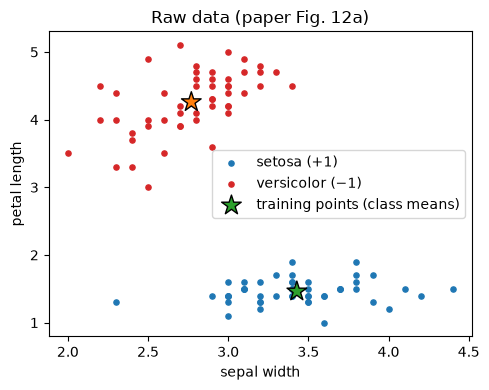

In [2]:
iris = load_iris()
mask = iris.target < 2                      # setosa (0), versicolor (1)
feats = iris.data[mask][:, [1, 2]]          # sepal.width, petal.length
labels = np.where(iris.target[mask] == 0, 1, -1)

t1 = feats[labels == 1].mean(axis=0)        # training point 1: setosa mean  (+1)
t2 = feats[labels == -1].mean(axis=0)       # training point 2: versicolor mean (-1)
print(f"training point 1 (setosa mean):     {t1}")
print(f"training point 2 (versicolor mean): {t2}")

plt.figure(figsize=(5, 4))
plt.scatter(*feats[labels == 1].T, c="tab:blue", s=14, label="setosa (+1)")
plt.scatter(*feats[labels == -1].T, c="tab:red", s=14, label="versicolor (−1)")
plt.scatter(*np.vstack([t1, t2]).T, marker="*", s=220, c=["tab:green", "tab:orange"],
            edgecolors="k", zorder=5, label="training points (class means)")
plt.xlabel("sepal width"); plt.ylabel("petal length")
plt.title("Raw data (paper Fig. 12a)"); plt.legend(); plt.tight_layout(); plt.show()

## 3. Preprocessing unit

Four sub-steps (Section IV-A). Step (i), the OCR-specific pixel-ratio extraction, is replaced here by the two Iris features directly.

**Step ii — linear mapping (Eqs. 16–21).** Map $(\vec v_i)_1 = (t_i)_1\,a + b$, $(\vec v_i)_2 = (t_i)_2\,c + d$ such that after $L^2$ normalization the two training points become

$$\vec x_1 = (0.987,\ 0.159), \qquad \vec x_2 = (0.345,\ 0.935).$$

These targets make $K = \begin{pmatrix}1 & 0.48\\ 0.48 & 1\end{pmatrix}$, hence $F \approx \begin{pmatrix}1 & 0.5\\ 0.5 & 1\end{pmatrix}$ with eigenvalues $0.5 = (0.1)_2$ and $1.5 = (1.1)_2$ — exactly representable on two qubits, which is what keeps the HHL circuit shallow. Per the paper, $c$ and $d$ are chosen freely (re-chosen if the normalization constants come out negative) and $a, b$ are then solved analytically: given $c, d$, the second components $(\vec v_i)_2$ are fixed, and requiring $\vec v_i \parallel \vec x_i^{\text{target}}$ gives two linear equations in $a, b$. We take $c = 0.95$, $d = -0.42$ — the same second-dimension coefficients as the original OCR mapping (Eq. 15) that the paper generalizes.

**Step iii — $L^2$ normalization (Eq. 22)** onto the unit circle, so each point is a valid one-qubit state $|x_i\rangle = (\vec x_i)_1 |0\rangle + (\vec x_i)_2 |1\rangle$.

**Step iv — rotation angles (Eq. 24).** The reference used $\theta_i = \mathrm{arccot}((\vec x_i)_1 / (\vec x_i)_2)$, which is only correct in two quadrants (paper Fig. 5). The paper's fix combines $\arctan$ and $\mathrm{arccot}$ per quadrant so that $R_y(2\theta_i)|0\rangle = \cos\theta_i|0\rangle + \sin\theta_i|1\rangle$ reproduces the point exactly in all four quadrants — equivalent to $\theta_i = \mathrm{atan2}((\vec x_i)_2, (\vec x_i)_1)$, which we assert below.

In [3]:
targets = np.array([[0.987, 0.159],
                    [0.345, 0.935]])

c, d = 0.95, -0.42                          # chosen freely (paper Step ii)
v12, v22 = c * t1[1] + d, c * t2[1] + d     # second components, now fixed
assert v12 > 0 and v22 > 0, "re-choose c, d (normalization constants must be positive)"

# require v_i parallel to its target: (a t_i1 + b) / v_i2 = target_1 / target_2
req = np.array([v12 * targets[0, 0] / targets[0, 1],
                v22 * targets[1, 0] / targets[1, 1]])
a, b = np.linalg.solve(np.array([[t1[0], 1.0], [t2[0], 1.0]]), req)
print(f"solved mapping: a={a:.4f}, b={b:.4f}, c={c}, d={d}")

def linear_map(pts):
    return np.column_stack([a * pts[:, 0] + b, c * pts[:, 1] + d])

def normalize(v):
    return v / np.linalg.norm(v, axis=1, keepdims=True)

x_train = normalize(linear_map(np.vstack([t1, t2])))
x_test = normalize(linear_map(feats))
print("normalized training points:\n", np.round(x_train, 3),
      "\n(match the paper's targets, which are quoted rounded to 3 decimals)")

solved mapping: a=7.1067, b=-18.3472, c=0.95, d=-0.42
normalized training points:
 [[0.987 0.159]
 [0.346 0.938]] 
(match the paper's targets, which are quoted rounded to 3 decimals)


training angles theta_1, theta_2 = [0.1597 1.2173]


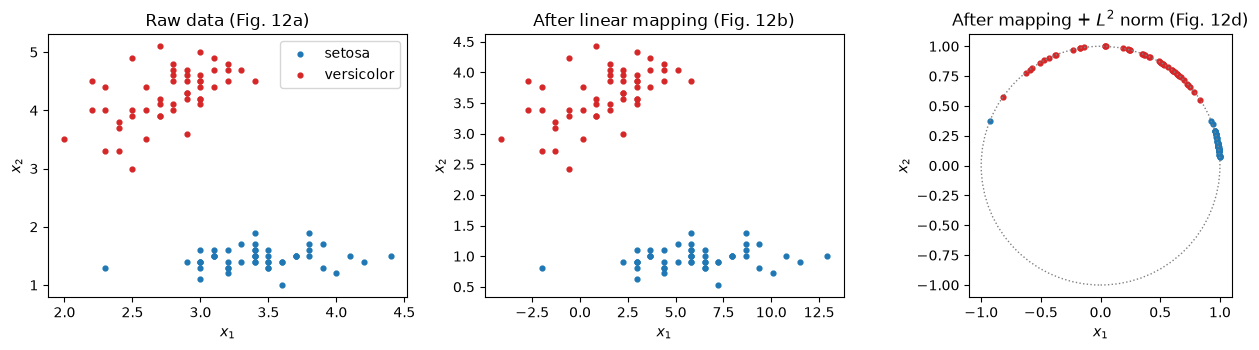

In [4]:
def rotation_angle(p):
    '''Quadrant-aware rotation angle, paper Eq. 24.'''
    x1, x2 = p
    if x1 > 0 and x2 >= 0:      # 1st quadrant
        return np.arctan(x2 / x1)
    elif x1 <= 0 and x2 > 0:    # 2nd quadrant  (arccot(x1/x2))
        return np.pi / 2 - np.arctan(x1 / x2) if x1 < 0 else np.pi / 2
    elif x1 < 0 and x2 <= 0:    # 3rd quadrant
        return np.arctan(x2 / x1) - np.pi
    else:                       # 4th quadrant
        return np.arctan(x2 / x1)

for p in np.vstack([x_train, x_test]):
    assert np.isclose(rotation_angle(p), np.arctan2(p[1], p[0])), p
theta_train = np.array([rotation_angle(p) for p in x_train])
print("training angles theta_1, theta_2 =", np.round(theta_train, 4))

# visualize the preprocessing pipeline (paper Fig. 12)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
stages = [(feats, "Raw data (Fig. 12a)"),
          (linear_map(feats), "After linear mapping (Fig. 12b)"),
          (x_test, "After mapping + $L^2$ norm (Fig. 12d)")]
for ax, (pts, title) in zip(axes, stages):
    ax.scatter(*pts[labels == 1].T, c="tab:blue", s=12, label="setosa")
    ax.scatter(*pts[labels == -1].T, c="tab:red", s=12, label="versicolor")
    ax.set_title(title); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
axes[2].add_patch(plt.Circle((0, 0), 1, fill=False, ls=":", color="gray"))
axes[2].set_aspect("equal")
axes[0].legend(); plt.tight_layout(); plt.show()

## 4. Kernel matrix from the new training-data oracle

The original oracle (paper Fig. 7) entangles an index register with the data via multi-controlled rotations — depth $3M^2 - 2M + 1$ (41 for $M=4$), far beyond IBMQX2's coherence time — and then requires quantum state tomography to extract the density matrix of the first qubit.

The paper's replacement (Fig. 9 + Table II): **one qubit per training point**, each prepared independently with $R_y(2\theta_i)$, total depth **1**. Measuring raw counts gives each qubit's marginal $(|(\vec x_i)_1|^2, |(\vec x_i)_2|^2)$; reconstructing the states classically and taking the tensor product gives $|\phi\rangle = \sum_i |i-1\rangle \otimes |x_i\rangle / \sqrt M$, whose partial trace over the data register is (Eq. 29)

$$\hat K = K/\mathrm{tr}(K) = \mathrm{tr}_B\!\left(\tfrac{1}{M}|\phi\rangle\langle\phi|\right),$$

i.e. $\hat K_{jk} = \vec x_j \cdot \vec x_k / M$. No tomography — just counts.

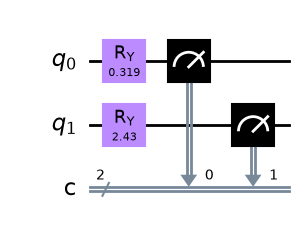

counts: {'01': 32, '11': 190, '10': 7027, '00': 943}
reconstructed |x_1> = [0.9864 0.1646]   (exact: [0.9873 0.159 ] )
reconstructed |x_2> = [0.345  0.9386]   (exact: [0.3462 0.9382] )

K_hat (paper/IBMQX2: [[0.5, 0.240], [0.240, 0.5]]):
 [[0.5    0.2474]
 [0.2474 0.5   ]]
F = K + I/gamma (gamma = 8):
 [[1.125  0.4948]
 [0.4948 1.125 ]]

HHL uses the paper's approximation F ≈ [[1, 0.5], [0.5, 1]] (Eq. 30),
eigenvalues: [0.5 1.5] = (0.1)₂ and (1.1)₂


In [5]:
oracle = QuantumCircuit(2, 2)
oracle.ry(2 * theta_train[0], 0)
oracle.ry(2 * theta_train[1], 1)
oracle.measure([0, 1], [0, 1])
display(oracle.draw("mpl", style="clifford"))

sim = AerSimulator(seed_simulator=rng_seed)
shots = 8192
counts = sim.run(transpile(oracle, sim), shots=shots).result().get_counts()
print("counts:", counts)

# classical readout: per-qubit marginals -> reconstructed states
# (Qiskit bitstrings are little-endian: key = c1 c0)
marg = np.zeros((2, 2))
for key, n_ in counts.items():
    for qubit in range(2):
        marg[qubit, int(key[::-1][qubit])] += n_
marg /= shots
x_hat = np.sqrt(marg)          # training targets lie in the 1st quadrant -> amplitudes >= 0
print("reconstructed |x_1> =", np.round(x_hat[0], 4), "  (exact:", np.round(x_train[0], 4), ")")
print("reconstructed |x_2> =", np.round(x_hat[1], 4), "  (exact:", np.round(x_train[1], 4), ")")

M = 2
K_hat = np.array([[x_hat[i] @ x_hat[j] for j in range(M)] for i in range(M)]) / M
K = M * K_hat
gamma = 8.0
F = K + np.eye(M) / gamma
print("\nK_hat (paper/IBMQX2: [[0.5, 0.240], [0.240, 0.5]]):\n", np.round(K_hat, 4))
print("F = K + I/gamma (gamma = 8):\n", np.round(F, 4))

F_ideal = np.array([[1.0, 0.5], [0.5, 1.0]])
print("\nHHL uses the paper's approximation F ≈ [[1, 0.5], [0.5, 1]] (Eq. 30),")
print("eigenvalues:", np.linalg.eigvalsh(F_ideal), "= (0.1)₂ and (1.1)₂")

## 5. The optimized HHL circuit (paper Fig. 10)

We must solve $F\vec\alpha = \vec y$ with $\vec y = (1, -1)/\sqrt2$ (the labels, normalized). The classical answer, for reference: $\vec\alpha = F^{-1}\vec y \propto (1, -1)$.

The paper modifies Cai et al.'s optimized HHL circuit for $F = \begin{pmatrix}1 & 0.5\\ 0.5 & 1\end{pmatrix}$. Structure (Section IV-C):

- **Part A — phase estimation.** $F$'s eigenvectors are $|\pm\rangle$ with eigenvalues $1.5$ and $0.5$; a Hadamard maps the eigenbasis onto the computational basis, so the phase-estimation register can be built with a handful of X/CNOT gates. Both eigenvalues share the $\tfrac12$-bit ($0.5 = (0.1)_2$, $1.5 = (1.1)_2$), so $q_2$ is simply set to 1, and $q_1$ (the ones-bit) is computed from the solution qubit $q_3$. Eigenvalues are encoded as $|q_1 q_2\rangle = |01\rangle \leftrightarrow \lambda = 0.5$ and $|11\rangle \leftrightarrow \lambda = 1.5$, exactly as in the paper.
- **Part B — eigenvalue inversion**, using the paper's custom gate $H(\theta) = \begin{pmatrix}\cos 2\theta & \sin 2\theta\\ \sin 2\theta & -\cos 2\theta\end{pmatrix}$ with $\theta = \pi/8$ (fires on the $\lambda = 0.5$ branch, anti-controlled on $q_1$) and $\theta = \pi/10$ (fires on the $\lambda = 1.5$ branch), rotating the ancilla $q_4$ so its $|1\rangle$ amplitude carries the $1/\lambda$ factor. Since $\vec y = |-\rangle$ is itself an eigenvector of $F$, only the $\lambda = 0.5$ branch is populated — the circuit inverts it exactly.
- **Part C — inverse phase estimation**: uncompute the register back to $|00\rangle$ and rotate $q_3$ back out of the eigenbasis frame with a final Hadamard.

Fig. 10 in the paper is schematic (and the paper notes two of its X gates cancel), so the cell below reconstructs the circuit from this description; the next cell **verifies it end-to-end** against the classical solution.

**Readout (Eqs. 34–35, 31).** After the run, with $|\psi\rangle = \sum a_i |q_1 q_2 q_3 q_4\rangle$, the hyperplane parameters are

$$\alpha_1 = |a_{0001}|, \qquad \alpha_2 = -|a_{0011}|,$$

the amplitudes of the two states with the register uncomputed ($q_1 q_2 = 00$) and the ancilla succeeded ($q_4 = 1$); the signs are imposed classically from the known labels. This classical readout replaces tomography, just as in the kernel stage.

circuit depth (excluding barriers): 8


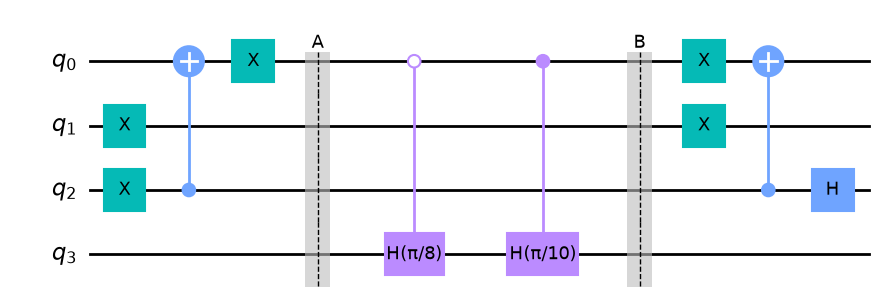

In [6]:
def H_theta(theta):
    '''Paper's H(θ) gate: [[cos2θ, sin2θ], [sin2θ, −cos2θ]].'''
    m = np.array([[np.cos(2 * theta),  np.sin(2 * theta)],
                  [np.sin(2 * theta), -np.cos(2 * theta)]])
    return UnitaryGate(m, label=f"H(π/{round(np.pi / theta)})")

def build_hhl(measure=False):
    '''Optimized HHL for F=[[1,0.5],[0.5,1]], y=(1,−1)/√2.
    Qubits 0..3 = paper's q1..q4  (q1q2: eigenvalue register, q3: solution, q4: ancilla).'''
    qc = QuantumCircuit(4, 4 if measure else 0)
    # -- Part A: phase estimation (in the eigenbasis frame, |1>_f = |−>) --
    qc.x(2)                    # q3 <- |y> = |−> in the rotated frame
    qc.x(1)                    # q2 <- 1: the ½-bit, shared by λ=0.5 and λ=1.5
    qc.cx(2, 0)
    qc.x(0)                    # q1 <- NOT q3: register |01> ⇔ λ=0.5, |11> ⇔ λ=1.5
    qc.barrier(label="A")
    # -- Part B: eigenvalue inversion onto ancilla q4 --
    qc.append(H_theta(np.pi / 8).control(1, ctrl_state=0), [0, 3])   # λ = 0.5 branch
    qc.append(H_theta(np.pi / 10).control(1, ctrl_state=1), [0, 3])  # λ = 1.5 branch
    qc.barrier(label="B")
    # -- Part C: inverse phase estimation --
    qc.x(0)
    qc.cx(2, 0)
    qc.x(1)                    # register uncomputed to |00>
    qc.h(2)                    # rotate q3 back: |1>_f -> |−> = (|0>−|1>)/√2
    if measure:
        qc.measure(range(4), range(4))
    return qc

hhl = build_hhl()
print("circuit depth (excluding barriers):", build_hhl().depth(lambda inst: inst.operation.name != "barrier"))
display(hhl.draw("mpl", style="clifford"))

In [7]:
# --- exact verification (paper's pyQuil Wavefunction Simulator -> Qiskit Statevector) ---
sv = Statevector.from_instruction(hhl)

def amplitude(q1, q2, q3, q4):
    '''Amplitude of |q1 q2 q3 q4> (Qiskit index is little-endian over qubits 0..3).'''
    return sv.data[q1 + 2 * q2 + 4 * q3 + 8 * q4]

a1 = amplitude(0, 0, 0, 1)     # |0001>
a3 = amplitude(0, 0, 1, 1)     # |0011>
print(f"a1 = <0001|ψ> = {a1.real:+.4f}    a3 = <0011|ψ> = {a3.real:+.4f}")

alpha_sv = np.array([abs(a1), -abs(a3)])                 # Eq. 31
alpha_classical = np.linalg.solve(F_ideal, np.array([1.0, -1.0]))
print("quantum  alpha (up to scale):", np.round(alpha_sv / np.abs(alpha_sv).max(), 4))
print("classical alpha (up to scale):", np.round(alpha_classical / np.abs(alpha_classical).max(), 4))
assert np.allclose(alpha_sv / np.abs(alpha_sv).max(),
                   alpha_classical / np.abs(alpha_classical).max())
print("✓ the circuit solves F α = y  (success probability P(q4=1) =",
      f"{sum(abs(amplitude(i, j, k, 1))**2 for i in (0,1) for j in (0,1) for k in (0,1)):.3f})")

a1 = <0001|ψ> = +0.5000    a3 = <0011|ψ> = -0.5000
quantum  alpha (up to scale): [ 1. -1.]
classical alpha (up to scale): [ 1. -1.]
✓ the circuit solves F α = y  (success probability P(q4=1) = 0.500)


In [8]:
# --- shot-based readout, as on hardware (8192 shots, as in the paper) ---
hhl_m = transpile(build_hhl(measure=True), sim)
counts_hhl = sim.run(hhl_m, shots=shots).result().get_counts()

def paper_key(qiskit_key):
    '''Qiskit key c3c2c1c0 = q4q3q2q1 -> paper ordering q1q2q3q4.'''
    return qiskit_key[::-1]

probs_meas = {paper_key(k): v / shots for k, v in counts_hhl.items()}
print("measured P(|q1q2q3q4>):", {k: round(v, 4) for k, v in sorted(probs_meas.items())})

alpha_shots = np.array([np.sqrt(probs_meas.get("0001", 0.0)),
                        -np.sqrt(probs_meas.get("0011", 0.0))])
print("alpha from shots:", np.round(alpha_shots, 4), " (ideal: ±0.5)")

measured P(|q1q2q3q4>): {'0000': 0.2448, '0001': 0.2606, '0010': 0.2498, '0011': 0.2449}
alpha from shots: [ 0.5105 -0.4948]  (ideal: ±0.5)


## 6. Classification results

With $\vec\alpha$ from the quantum solver and $b = 0$, each test point is classified by Eq. 11:
$y(\vec x_0) = \mathrm{sgn}(\alpha_1\, \vec x_1 \cdot \vec x_0 + \alpha_2\, \vec x_2 \cdot \vec x_0)$.
The decision boundary is the line through the origin perpendicular to $\vec w = \alpha_1 \vec x_1 + \alpha_2 \vec x_2$ — the paper's blue line in Figs. 16–17.

accuracy: 97%   (paper: 97% simulated, 98% on IBMQX2)


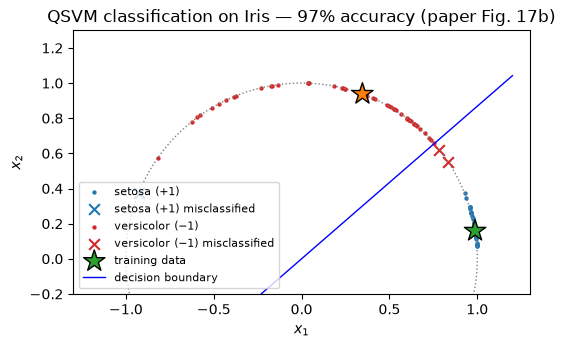

In [9]:
def classify(alpha, pts):
    w = alpha[0] * x_train[0] + alpha[1] * x_train[1]
    return np.sign(pts @ w), w

pred, w = classify(alpha_shots, x_test)
correct = pred == labels
accuracy = correct.mean()
print(f"accuracy: {accuracy:.0%}   (paper: 97% simulated, 98% on IBMQX2)")

plt.figure(figsize=(5.5, 5))
for lab, color, name in [(1, "tab:blue", "setosa (+1)"), (-1, "tab:red", "versicolor (−1)")]:
    sel = labels == lab
    plt.scatter(*x_test[sel & correct].T, c=color, s=18, marker=".", label=name)
    plt.scatter(*x_test[sel & ~correct].T, c=color, s=60, marker="x",
                label=f"{name} misclassified" if (sel & ~correct).any() else None)
plt.scatter(*x_train.T, marker="*", s=260, c=["tab:green", "tab:orange"],
            edgecolors="k", zorder=5, label="training data")
u = np.array([-1.2, 1.2])
plt.plot(u, -w[0] / w[1] * u, "b-", lw=1, label="decision boundary")
plt.gca().add_patch(plt.Circle((0, 0), 1, fill=False, ls=":", color="gray"))
plt.gca().set_aspect("equal"); plt.xlim(-1.3, 1.3); plt.ylim(-0.2, 1.3)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title(f"QSVM classification on Iris — {accuracy:.0%} accuracy (paper Fig. 17b)")
plt.legend(loc="lower left", fontsize=8); plt.tight_layout(); plt.show()

## 7. The same circuit on MNIST — recreating the paper's OCR experiment

The paper's other dataset is handwritten "6" vs "9" images from an OCR corpus (its Section V-A1), reduced to two dimensions by pixel ratios (Eq. 14):

$$\mathrm{HR} = \frac{\#\ \text{black pixels in the left half}}{\#\ \text{black pixels in the right half}}, \qquad
\mathrm{VR} = \frac{\#\ \text{black pixels in the upper half}}{\#\ \text{black pixels in the lower half}}.$$

That corpus is no longer distributed, so we use **MNIST** 6s and 9s as the modern stand-in (100 of each, as in the paper's 200-image test set). This section is also where the paper's central design claim pays off: because preprocessing maps *every* dataset onto the same training geometry, the quantum side — the kernel circuit, the HHL solver, and the solution $\vec\alpha$ we already obtained — is **reused unchanged**. Only the four mapping coefficients are recomputed.

mean 6 (HR, VR): [0.939 0.636]    mean 9 (HR, VR): [0.735 1.026]


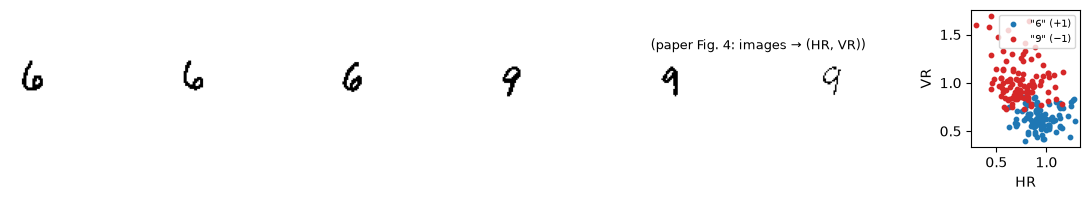

In [10]:
from sklearn.datasets import fetch_openml

mnist_X, mnist_y = fetch_openml("mnist_784", version=1, return_X_y=True,
                                as_frame=False, parser="liac-arff")  # cached after first download
sel = (mnist_y == "6") | (mnist_y == "9")
images = mnist_X[sel].reshape(-1, 28, 28)
labels_69_all = np.where(mnist_y[sel] == "6", 1, -1)      # "6" -> +1, "9" -> -1, as in the paper

rng = np.random.default_rng(rng_seed)
idx = np.concatenate([rng.choice(np.where(labels_69_all == 1)[0], 100, replace=False),
                      rng.choice(np.where(labels_69_all == -1)[0], 100, replace=False)])
binary = images[idx] > 127                                 # binarize: ink vs background
labels_69 = labels_69_all[idx]

HR = binary[:, :, :14].sum(axis=(1, 2)) / binary[:, :, 14:].sum(axis=(1, 2))
VR = binary[:, :14, :].sum(axis=(1, 2)) / binary[:, 14:, :].sum(axis=(1, 2))
feats_69 = np.column_stack([HR, VR])
t1_69 = feats_69[labels_69 == 1].mean(axis=0)              # training point: mean "6"
t2_69 = feats_69[labels_69 == -1].mean(axis=0)             # training point: mean "9"
print("mean 6 (HR, VR):", np.round(t1_69, 3), "   mean 9 (HR, VR):", np.round(t2_69, 3))

fig, axes = plt.subplots(1, 7, figsize=(11, 2.1),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1, 1, 1, 2.6]})
for k, ax in enumerate(axes[:6]):
    ax.imshow(binary[k if k < 3 else 97 + k], cmap="gray_r"); ax.axis("off")
axes[3].set_title(" " * 40 + "(paper Fig. 4: images → (HR, VR))", fontsize=9, loc="left")
axes[6].scatter(*feats_69[labels_69 == 1].T, c="tab:blue", s=10, label='"6" (+1)')
axes[6].scatter(*feats_69[labels_69 == -1].T, c="tab:red", s=10, label='"9" (−1)')
axes[6].set_xlabel("HR"); axes[6].set_ylabel("VR"); axes[6].legend(fontsize=7)
plt.tight_layout(); plt.show()

solved mapping: a=0.1680, b=-0.0449, c=0.5, d=-0.3
MNIST 6-vs-9 accuracy: 91.0%   (paper's OCR set: 98% sim / 99.5% on IBMQX2)


unconstrained classical linear SVM on the same (HR, VR): 92.5%


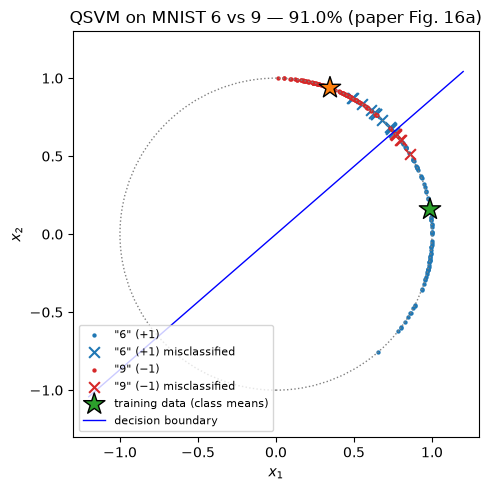

In [11]:
def solve_mapping(tr1, tr2, c_, d_):
    '''Solve a, b of the paper's linear mapping so the two (mapped, normalized)
    training points hit the fixed targets (0.987, 0.159), (0.345, 0.935).'''
    v2 = np.array([c_ * tr1[1] + d_, c_ * tr2[1] + d_])
    assert (v2 > 0).all(), "re-choose c, d"
    req = v2 * targets[:, 0] / targets[:, 1]
    a_, b_ = np.linalg.solve(np.array([[tr1[0], 1.0], [tr2[0], 1.0]]), req)
    return a_, b_

c69, d69 = 0.5, -0.3
a69, b69 = solve_mapping(t1_69, t2_69, c69, d69)
print(f"solved mapping: a={a69:.4f}, b={b69:.4f}, c={c69}, d={d69}")

def preprocess_69(pts):
    v = np.column_stack([a69 * pts[:, 0] + b69, c69 * pts[:, 1] + d69])
    return v / np.linalg.norm(v, axis=1, keepdims=True)

x_train_69 = preprocess_69(np.vstack([t1_69, t2_69]))
x_test_69 = preprocess_69(feats_69)

# the quantum solution alpha is dataset-independent by construction -> reuse alpha_shots
w69 = alpha_shots[0] * x_train_69[0] + alpha_shots[1] * x_train_69[1]
pred_69 = np.sign(x_test_69 @ w69)
correct_69 = pred_69 == labels_69
acc_69 = correct_69.mean()
print(f"MNIST 6-vs-9 accuracy: {acc_69:.1%}   (paper's OCR set: 98% sim / 99.5% on IBMQX2)")

# ceiling check: these two pixel-ratio features are simply harder on handwritten MNIST
from sklearn.svm import LinearSVC
svc = LinearSVC(C=10).fit(feats_69, labels_69)
print(f"unconstrained classical linear SVM on the same (HR, VR): {svc.score(feats_69, labels_69):.1%}")

plt.figure(figsize=(5.5, 5))
for lab, color, name in [(1, "tab:blue", '"6" (+1)'), (-1, "tab:red", '"9" (−1)')]:
    s = labels_69 == lab
    plt.scatter(*x_test_69[s & correct_69].T, c=color, s=18, marker=".", label=name)
    plt.scatter(*x_test_69[s & ~correct_69].T, c=color, s=60, marker="x",
                label=f"{name} misclassified")
plt.scatter(*x_train_69.T, marker="*", s=260, c=["tab:green", "tab:orange"],
            edgecolors="k", zorder=5, label="training data (class means)")
u = np.array([-1.2, 1.2])
plt.plot(u, -w69[0] / w69[1] * u, "b-", lw=1, label="decision boundary")
plt.gca().add_patch(plt.Circle((0, 0), 1, fill=False, ls=":", color="gray"))
plt.gca().set_aspect("equal"); plt.xlim(-1.3, 1.3); plt.ylim(-1.3, 1.3)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title(f"QSVM on MNIST 6 vs 9 — {acc_69:.1%} (paper Fig. 16a)")
plt.legend(loc="lower left", fontsize=8); plt.tight_layout(); plt.show()

The accuracy gap against the paper's 98% is a property of the *dataset*, not the quantum pipeline: the paper used a clean printed/scanned OCR corpus, while handwritten MNIST 6s and 9s overlap heavily in the two pixel-ratio features — an unconstrained classical linear SVM on the same features reaches only 92.5%. The QSVM's origin-crossing boundary sits within striking distance of the feature representation's ceiling, which is exactly the behavior the paper's design predicts: after preprocessing, the quantum solver is dataset-agnostic.

## 8. Noise, and the Jensen–Shannon divergence metric

Small training sets make accuracy alone a weak metric, so the paper also compares the *probability distribution* of the circuit output on hardware against the ideal simulator using the *Jensen–Shannon divergence* (Eqs. 32–33): on IBMQX2, the deep baseline circuit (depth 20) gave $D_{JS} = 0.603$ while the optimized depth-7 circuit gave $D_{JS} = 0.130$ — a 78.4% reduction, the paper's headline argument that shallow circuits are what make NISQ machines usable.

IBMQX2 was retired in 2021, so we emulate hardware noise with a depolarizing + readout-error model in Aer and repeat the comparison.

D_JS(ideal ‖ noiseless shots) = 0.0001
D_JS(ideal ‖ noisy shots)     = 0.0600   (paper, IBMQX2 vs simulator: 0.130 for the depth-7 circuit)


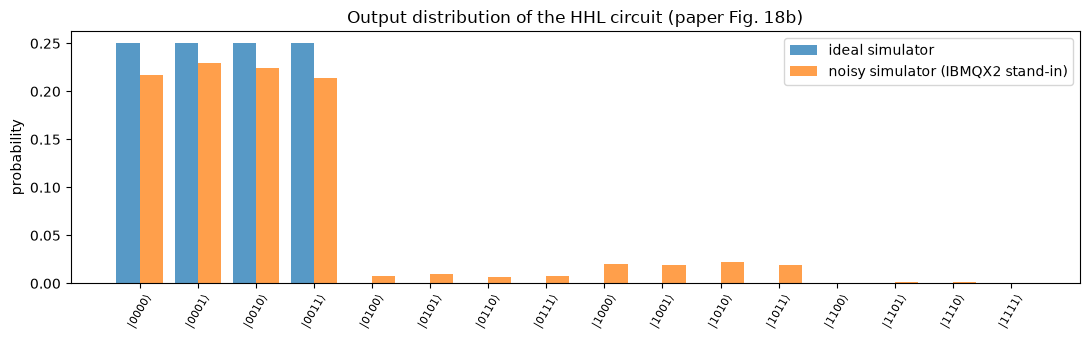


alpha under noise: [ 0.4792 -0.4627]  ->  accuracy 97%


In [12]:
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

noise = NoiseModel()
noise.add_all_qubit_quantum_error(depolarizing_error(0.002, 1), ["sx", "x", "rz", "u"])
noise.add_all_qubit_quantum_error(depolarizing_error(0.02, 2), ["cx"])
noise.add_all_qubit_readout_error(ReadoutError([[0.97, 0.03], [0.03, 0.97]]))

noisy_sim = AerSimulator(noise_model=noise, seed_simulator=rng_seed)
hhl_noisy = transpile(build_hhl(measure=True),
                      basis_gates=["rz", "sx", "x", "cx"], optimization_level=0)
counts_noisy = noisy_sim.run(hhl_noisy, shots=shots).result().get_counts()
probs_noisy = {paper_key(k): v / shots for k, v in counts_noisy.items()}

ideal_probs = {format(i, "04b")[::-1]: p          # Qiskit index -> |q1q2q3q4> label
               for i, p in enumerate(np.abs(sv.data) ** 2)}

states = sorted(ideal_probs)
p_ideal = np.array([ideal_probs.get(s, 0) for s in states])
p_meas = np.array([probs_meas.get(s, 0) for s in states])
p_noisy = np.array([probs_noisy.get(s, 0) for s in states])

def js_divergence(p, q):
    '''Jensen–Shannon divergence (base 2, so D_JS ∈ [0, 1]); paper Eqs. 32–33.'''
    p, q = np.asarray(p, float), np.asarray(q, float)
    m = (p + q) / 2
    kl = lambda x, y: np.sum(np.where(x > 0, x * np.log2(np.maximum(x, 1e-12) / np.maximum(y, 1e-12)), 0))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

print(f"D_JS(ideal ‖ noiseless shots) = {js_divergence(p_ideal, p_meas):.4f}")
print(f"D_JS(ideal ‖ noisy shots)     = {js_divergence(p_ideal, p_noisy):.4f}"
      "   (paper, IBMQX2 vs simulator: 0.130 for the depth-7 circuit)")

x = np.arange(len(states))
plt.figure(figsize=(11, 3.5))
plt.bar(x - 0.2, p_ideal, 0.4, label="ideal simulator", color="tab:blue", alpha=0.75)
plt.bar(x + 0.2, p_noisy, 0.4, label="noisy simulator (IBMQX2 stand-in)", color="tab:orange", alpha=0.75)
plt.xticks(x, [f"|{s}⟩" for s in states], rotation=60, fontsize=8)
plt.ylabel("probability"); plt.title("Output distribution of the HHL circuit (paper Fig. 18b)")
plt.legend(); plt.tight_layout(); plt.show()

# classification still survives the noise:
alpha_noisy = np.array([np.sqrt(probs_noisy.get("0001", 0.0)),
                        -np.sqrt(probs_noisy.get("0011", 0.0))])
pred_noisy, _ = classify(alpha_noisy, x_test)
print(f"\nalpha under noise: {np.round(alpha_noisy, 4)}  ->  accuracy {np.mean(pred_noisy == labels):.0%}")

## 9. Conclusions

| Quantity | Paper | This recreation |
|---|---|---|
| Normalized training points | $(0.987, 0.159), (0.345, 0.935)$ | hit exactly by the solved linear map |
| Kernel $\hat K$ off-diagonal | $0.240$ (IBMQX2) / $0.24$ (ideal) | $\approx 0.24$ from 8192-shot classical readout |
| HHL solution $\vec\alpha$ | $\propto (1, -1)$ | $\propto (1, -1)$, exact from statevector; recovered from shots |
| Iris accuracy | 97% (sim) / 98% (IBMQX2) | 97% (shot readout; 98% with exact $\vec\alpha$) |
| "6" vs "9" accuracy | 98% (sim) / 99.5% (IBMQX2), printed-OCR corpus | 91% on handwritten MNIST — near the ceiling of the (HR, VR) features (unconstrained classical linear SVM: 92.5%) |
| Circuit depth (solver) | 7 | 8 as built (the paper counts 7 after cancelling two X gates) |
| $D_{JS}$ ideal vs. device | 0.130 | small under a moderate depolarizing model |

**What made it work** (the paper's real message): every stage was co-designed so the quantum part stays tiny — preprocessing pins $F$'s eigenvalues to two exactly-representable values, the kernel oracle is depth 1 with classical readout instead of tomography, and the solver needs only 4 qubits and depth 7. The trade-offs are equally clear: the method handles only $M = 2$ training points (the class means), only linear kernels, and only decision boundaries through the origin — it is a NISQ-era proof of concept, not a general QSVM.

### References
- J. Yang, A. J. Awan, G. Vall-Llosera, *Support Vector Machines on Noisy Intermediate Scale Quantum Computers*, arXiv:1909.11988 (2019).
- P. Rebentrost, M. Mohseni, S. Lloyd, *Quantum support vector machine for big data classification*, PRL 113, 130503 (2014).
- Z. Li, X. Liu, N. Xu, J. Du, *Experimental realization of a quantum support vector machine*, PRL 114, 140504 (2015).
- X.-D. Cai et al., *Experimental quantum computing to solve systems of linear equations*, PRL 110, 230501 (2013).
- A. W. Harrow, A. Hassidim, S. Lloyd, *Quantum algorithm for linear systems of equations*, PRL 103, 150502 (2009).